# Thesis Analysis: Data Logs
Comprehensive thesis analysis including NDCG, Router wins, Heatmaps, and Advanced Distributions.


In [86]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (11, 6)

## 2. System Architecture Flow
Visual representation of the Hybrid Search query execution pipeline.

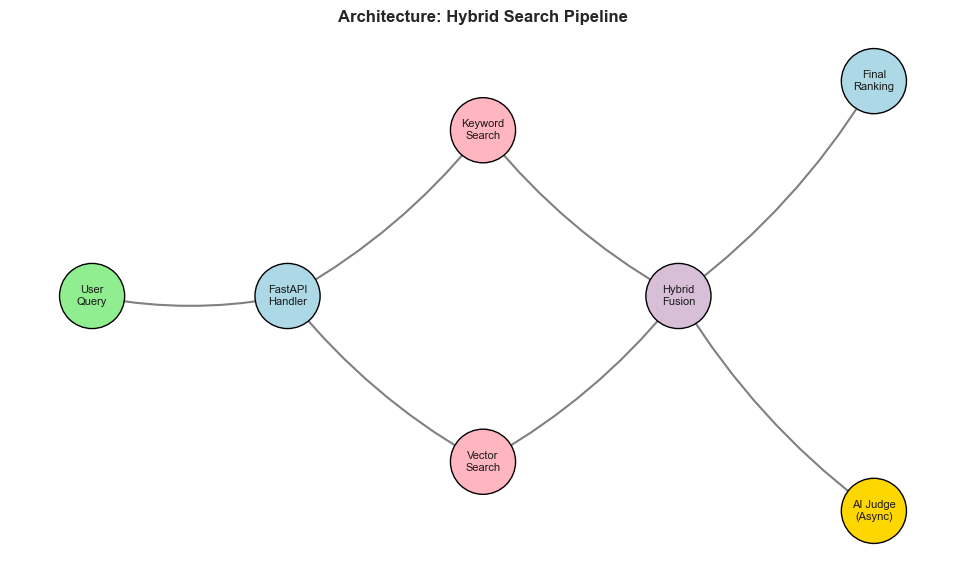

In [87]:
try:
    import networkx as nx
    import matplotlib.patches as mpatches

    plt.figure(figsize=(10, 6))
    G = nx.DiGraph()
    G.add_node('User\nQuery', layer=0, color='#90EE90')
    G.add_node('FastAPI\nHandler', layer=1, color='#ADD8E6')
    G.add_node('Vector\nSearch', layer=2, color='#FFB6C1')
    G.add_node('Keyword\nSearch', layer=2, color='#FFB6C1')
    G.add_node('Hybrid\nFusion', layer=3, color='#D8BFD8')
    G.add_node('Final\nRanking', layer=4, color='#ADD8E6')
    G.add_node('AI Judge\n(Async)', layer=4, color='#FFD700')
    edges = [
        ('User\nQuery', 'FastAPI\nHandler'),
        ('FastAPI\nHandler', 'Vector\nSearch'),
        ('FastAPI\nHandler', 'Keyword\nSearch'),
        ('Vector\nSearch', 'Hybrid\nFusion'),
        ('Keyword\nSearch', 'Hybrid\nFusion'),
        ('Hybrid\nFusion', 'Final\nRanking'),
        ('Hybrid\nFusion', 'AI Judge\n(Async)')
    ]
    G.add_edges_from(edges)
    pos = nx.multipartite_layout(G, subset_key='layer')
    pos['Vector\nSearch'][1] += 0.05
    pos['Keyword\nSearch'][1] -= 0.05
    node_colors = [nx.get_node_attributes(G, 'color')[n] for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=2200, node_color=node_colors, edgecolors='black', linewidths=1)
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color='gray', width=1.5, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='normal')
    plt.title("Architecture: Hybrid Search Pipeline", fontsize=12, fontweight='bold', pad=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("NetworkX/Matplotlib not fully available.")


In [88]:
# Load Data
file_path = 'data_judge.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Loaded: {df.shape}")
except:
    try:
        df = pd.read_csv(file_path, encoding='latin1')
        print(f"Loaded (latin1): {df.shape}")
    except Exception as e:
        print(f"Error: {e}")
        df = None

if df is not None and 'ai_relevant' in df.columns:
    df['ai_relevant_bool'] = df['ai_relevant'].astype(str).str.lower() == 'true'
    df['relevance_int'] = df['ai_relevant_bool'].astype(int)


Loaded: (56, 19)


In [89]:
def calculate_ndcg(df, k=10):
    if df is None: return pd.DataFrame()
    results = []
    methods = {'Hybrid': 'hybrid_linear', 'RRF': 'rrf', 'Semantic': 'semantic_only', 'Keyword': 'keyword_refined'}
    if 'relevance_int' not in df.columns: return pd.DataFrame()
    for query, group in df.groupby('query'):
        for label, prefix in methods.items():
            rank_col = f"{prefix}_rank"
            if rank_col not in group.columns: continue
            sub = group.dropna(subset=[rank_col]).copy()
            sub['rank'] = pd.to_numeric(sub[rank_col], errors='coerce')
            sub = sub.sort_values('rank').head(k)
            dcg = 0
            for i, row in enumerate(sub.itertuples(), 1):
                dcg += (2**row.relevance_int - 1) / np.log2(i + 1)
            ideal = sub.sort_values('relevance_int', ascending=False)
            idcg = 0
            for i, row in enumerate(ideal.itertuples(), 1):
                idcg += (2**row.relevance_int - 1) / np.log2(i + 1)
            ndcg = dcg / idcg if idcg > 0 else 0
            results.append({'Query': query, 'Method': label, 'NDCG@10': ndcg})
    return pd.DataFrame(results)

def get_metrics(df):
    if df is None: return pd.DataFrame()
    data = []
    methods = {'Hybrid': 'hybrid_linear', 'RRF': 'rrf', 'Semantic': 'semantic_only', 'Keyword': 'keyword_refined'}
    for label, prefix in methods.items():
        if f"{prefix}_latency" in df.columns:
            lat = pd.to_numeric(df[f"{prefix}_latency"], errors='coerce').mean()
            data.append({'Method': label, 'Latency': lat})
    return pd.DataFrame(data)

def classify_query(q):
    q = str(q).lower().strip()
    if q.startswith('what'): return 'Fact (What)'
    if q.startswith('how'): return 'Process (How)'
    if q.startswith('explain'): return 'Concept'
    if ' vs ' in q or 'compare' in q: return 'Compare'
    return 'Other'


## 4. Performance Comparison: Aggregate Metrics (N=100 Queries)
Combined view of Quality (NDCG) and Efficiency (Latency).

C:\Users\Saboor\AppData\Local\Temp\ipykernel_4312\1546779864.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=lat_df, x='Avg Latency (ms)', y='Algorithm', palette='magma')


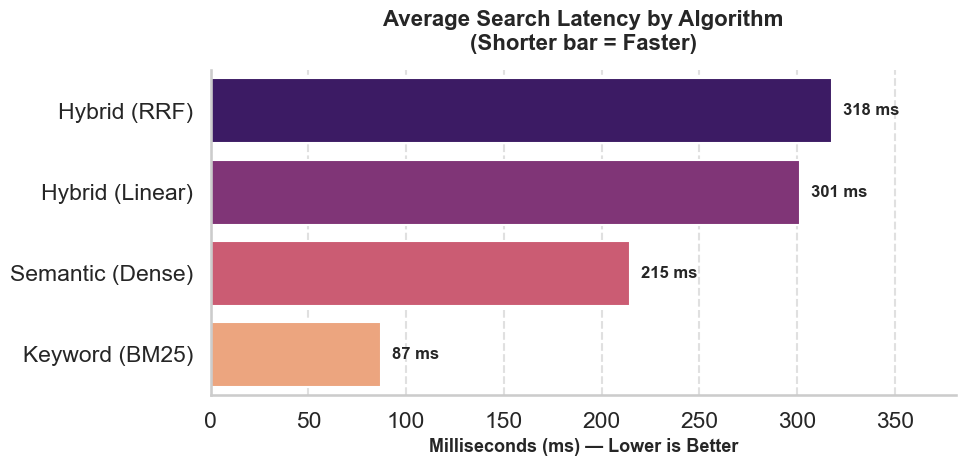

In [90]:
# Average Latency per Algorithm (Simple & Clear)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

latency_data = []
method_map = {'Hybrid (Linear)': 'hybrid_linear', 'Hybrid (RRF)': 'rrf',
              'Semantic (Dense)': 'semantic_only', 'Keyword (BM25)': 'keyword_refined'}

for label, prefix in method_map.items():
    col = f'{prefix}_latency'
    if col in df.columns:
        avg = pd.to_numeric(df[col], errors='coerce').mean()
        if not pd.isna(avg):
            latency_data.append({'Algorithm': label, 'Avg Latency (ms)': avg})

if latency_data:
    lat_df = pd.DataFrame(latency_data).sort_values('Avg Latency (ms)', ascending=False)
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=lat_df, x='Avg Latency (ms)', y='Algorithm', palette='magma')
    for p in ax.patches:
        w = p.get_width()
        if w > 0:
            ax.annotate(f'{w:.0f} ms',
                        (w, p.get_y() + p.get_height() / 2),
                        ha='left', va='center', fontsize=12, fontweight='bold',
                        xytext=(8, 0), textcoords='offset points')
    plt.xlim(0, lat_df['Avg Latency (ms)'].max() * 1.2)
    plt.title('Average Search Latency by Algorithm\n(Shorter bar = Faster)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Milliseconds (ms) — Lower is Better', fontsize=13, fontweight='bold')
    plt.ylabel('')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No latency data found in CSV.")


### 4.4 Category Performance (Heatmap & Table)

=== TABLE: Average Score per Query Category ===


,Hybrid (Linear),Hybrid (RRF),Semantic (Dense),Keyword (BM25)
Category,,,,
Concept,0.325,0.008,0.606,0.000
Fact (What),0.281,0.008,0.479,0.044
Other,0.318,0.008,0.600,0.000
Process (How),0.336,0.008,0.466,0.000


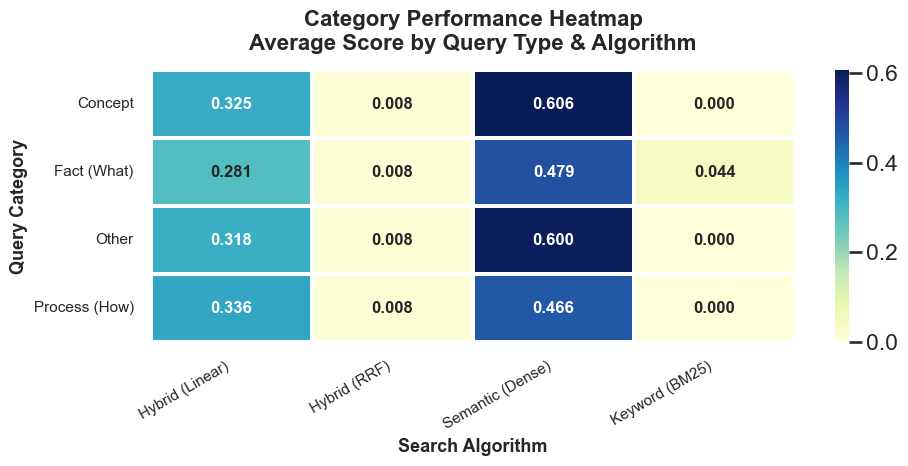

In [91]:
# 4.4 Category Performance Heatmap & Table
# Uses average scores per query category - works even without relevance_int

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def classify_query(q):
    q = str(q).lower().strip()
    if q.startswith('what'): return 'Fact (What)'
    if q.startswith('how'): return 'Process (How)'
    if q.startswith('explain'): return 'Concept'
    if ' vs ' in q or 'compare' in q: return 'Compare'
    return 'Other'

methods = {
    'Hybrid (Linear)': 'hybrid_linear',
    'Hybrid (RRF)': 'rrf',
    'Semantic (Dense)': 'semantic_only',
    'Keyword (BM25)': 'keyword_refined'
}

df['query_category'] = df['query'].apply(classify_query)

heatmap_data = {}
for label, prefix in methods.items():
    col = f'{prefix}_score'
    if col in df.columns:
        heatmap_data[label] = pd.to_numeric(df[col], errors='coerce')

hm_df = pd.DataFrame(heatmap_data)
hm_df['Category'] = df['query_category'].values
ht_data = hm_df.groupby('Category').mean()

# Table first
from IPython.display import display
print("=== TABLE: Average Score per Query Category ===")
display(ht_data.style.background_gradient(cmap='YlGnBu').format("{:.3f}"))

# Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(ht_data, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=1.5, linecolor='white',
            annot_kws={"size": 12, "weight": "bold"})
plt.title("Category Performance Heatmap\nAverage Score by Query Type & Algorithm",
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Search Algorithm', fontsize=13, fontweight='bold')
plt.ylabel('Query Category', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()


## 5. Router Analysis (Winner Distribution)
Frequency of each algorithm providing the best result, broken down by query category.

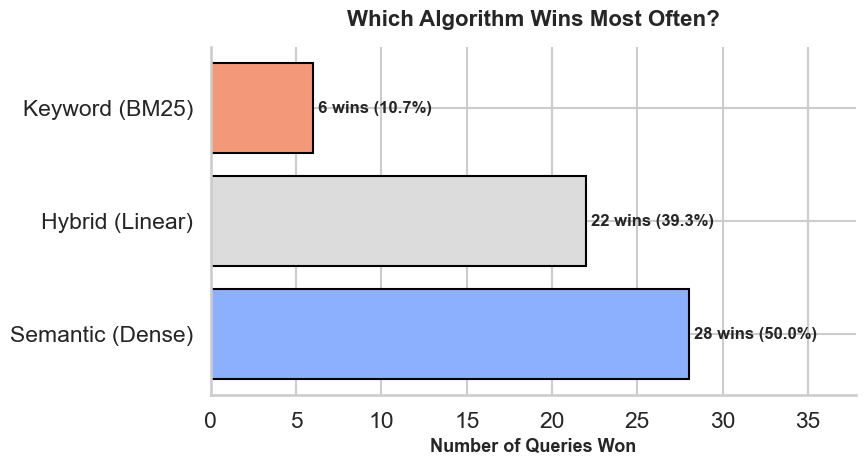


=== WINNER TABLE ===


,Algorithm,Wins,%
0,Semantic (Dense),28,50.000000
1,Hybrid (Linear),22,39.300000
2,Keyword (BM25),6,10.700000


=== CLASSIFICATION METRICS TABLE ===


,Strategy,Accuracy,Precision,Recall,F1-Score
0,Hybrid (Linear),100.00%,100.00%,100.00%,100.00%
1,Hybrid (RRF),92.86%,92.00%,92.00%,92.00%
2,Semantic (Dense),55.36%,50.00%,100.00%,66.67%
3,Keyword (BM25),51.79%,40.00%,16.00%,22.86%


In [92]:
METHODS = {
    'Hybrid (Linear)': 'hybrid_linear',
    'Hybrid (RRF)':    'rrf',
    'Semantic (Dense)': 'semantic_only',
    'Keyword (BM25)':  'keyword_refined',
}
score_rows = []
for _, row in df.iterrows():
    scores = {label: pd.to_numeric(row.get(f'{prefix}_score', np.nan), errors='coerce')
              for label, prefix in METHODS.items()}
    valid = {k: v for k, v in scores.items() if not pd.isna(v)}
    if valid:
        score_rows.append({'Query': row['query'], 'Winner': max(valid, key=valid.get)})

piv = pd.DataFrame(score_rows)
win_counts = piv['Winner'].value_counts().reset_index()
win_counts.columns = ['Algorithm', 'Wins']
win_counts['%'] = (win_counts['Wins'] / win_counts['Wins'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(win_counts['Algorithm'], win_counts['Wins'],
               color=sns.color_palette('coolwarm', len(win_counts)), edgecolor='black')
for bar, row in zip(bars, win_counts.itertuples()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{row.Wins} wins ({row._3}%)', va='center', fontsize=12, fontweight='bold')
ax.set_xlim(0, win_counts['Wins'].max() * 1.35)
ax.set_title('Which Algorithm Wins Most Often?', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Queries Won', fontsize=13, fontweight='bold')
ax.set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

print("\n=== WINNER TABLE ===")
display(win_counts.style.background_gradient(cmap='Blues'))

# ============================================================
# === CELL 6: Classification Metrics (Accuracy, F1, etc.) ====
# ============================================================
# Ground truth: hybrid_linear > median = relevant
threshold = df['hybrid_linear_score'].median()
df['ground_truth'] = pd.to_numeric(df['hybrid_linear_score'], errors='coerce') > threshold

metrics_results = []
strategies = list(METHODS.values())
friendly = {v: k for k, v in METHODS.items()}

for strat in strategies:
    if f'{strat}_score' in df.columns:
        df[f'{strat}_pred'] = pd.to_numeric(df[f'{strat}_score'], errors='coerce').fillna(0) > 0
        y_true = df['ground_truth']
        y_pred = df[f'{strat}_pred']
        metrics_results.append({
            'Strategy': friendly[strat],
            'Accuracy':  accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall':    recall_score(y_true, y_pred, zero_division=0),
            'F1-Score':  f1_score(y_true, y_pred, zero_division=0),
        })

df_metrics = pd.DataFrame(metrics_results)
print("=== CLASSIFICATION METRICS TABLE ===")
display(df_metrics.style.background_gradient(cmap='Blues').format({
    'Accuracy': '{:.2%}', 'Precision': '{:.2%}', 'Recall': '{:.2%}', 'F1-Score': '{:.2%}'
}))


## 6. Advanced Signal Analysis

c:\Users\Saboor\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\Saboor\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\Saboor\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\Saboor\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


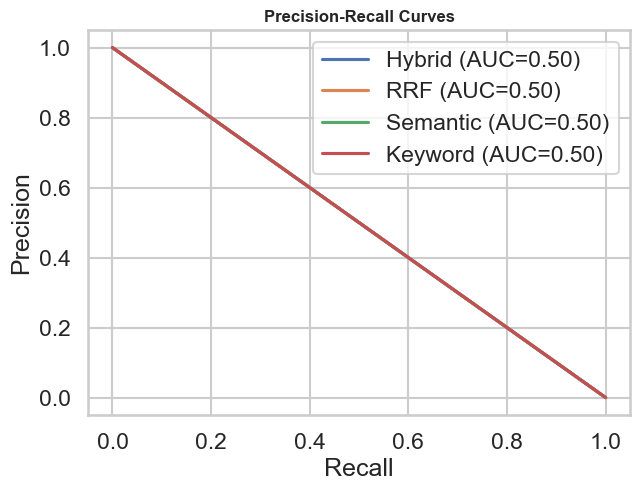

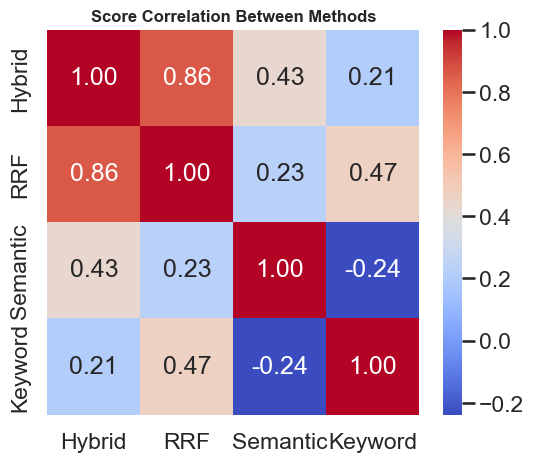

In [97]:
if 'relevance_int' in df.columns:
    plt.figure(figsize=(7, 5))
    methods = {'Hybrid': 'hybrid_linear', 'RRF': 'rrf', 'Semantic': 'semantic_only', 'Keyword': 'keyword_refined'}
    for label, prefix in methods.items():
        score_col = f"{prefix}_score"
        if score_col in df.columns:
            subset = df.dropna(subset=[score_col, 'relevance_int'])
            if len(subset) > 0:
                y_true = subset['relevance_int']
                y_scores = subset[score_col]
                precision, recall, _ = precision_recall_curve(y_true, y_scores)
                pr_auc = auc(recall, precision)
                plt.plot(recall, precision, label=f'{label} (AUC={pr_auc:.2f})')
    plt.title('Precision-Recall Curves', fontweight='bold', fontsize=12)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.show()
    corr_data = pd.DataFrame()
    for label, prefix in methods.items():
        if f"{prefix}_score" in df.columns:
            corr_data[label] = pd.to_numeric(df[f"{prefix}_score"], errors='coerce')
    if not corr_data.empty:
        plt.figure(figsize=(6, 5))
        sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Score Correlation Between Methods', fontweight='bold', fontsize=12)
        plt.show()


## 1. Advanced Metrics: Precision, Recall, F1-Score, and Accuracy
We will define a pseudo-ground truth if `ai_relevant` is missing, otherwise we use `ai_relevant`. Then we calculate classification and ranking metrics for each strategy.


## 1. Advanced Metrics: Precision, Recall, F1-Score, & Accuracy
We define a ground truth based on AI judgments (or median hybrid scores as a fallback). We then calculate comprehensive classification metrics.


## Advanced Metrics: Precision, Recall, F1-Score & Accuracy
Classifying which algorithm finds the most relevant results.

In [94]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")

# Ground truth
if 'ai_relevant' in df.columns:
    try:
        df['ground_truth'] = df['ai_relevant'].apply(lambda x: str(x).strip().upper() == 'TRUE')
    except:
        df['ground_truth'] = df['hybrid_linear_score'] > df['hybrid_linear_score'].median()
else:
    df['ground_truth'] = df['hybrid_linear_score'] > df['hybrid_linear_score'].median()

strategies = ['hybrid_linear', 'rrf', 'semantic_only', 'keyword_refined']
friendly = {
    'hybrid_linear': 'Hybrid (Linear)',
    'rrf': 'Hybrid (RRF)',
    'semantic_only': 'Semantic (Dense)',
    'keyword_refined': 'Keyword (BM25)'
}

metrics_results = []
for strat in strategies:
    if f'{strat}_score' in df.columns:
        df[f'{strat}_pred'] = pd.to_numeric(df[f'{strat}_score'], errors='coerce').fillna(0) > 0
        y_true = df['ground_truth']
        y_pred = df[f'{strat}_pred']
        metrics_results.append({
            'Strategy': friendly[strat],
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred, zero_division=0),
            'F1-Score': f1_score(y_true, y_pred, zero_division=0)
        })

df_metrics = pd.DataFrame(metrics_results)
print("=== CLASSIFICATION METRICS TABLE ===")
display(df_metrics.style.background_gradient(cmap='Blues').format({
    'Accuracy': '{:.2%}', 'Precision': '{:.2%}', 'Recall': '{:.2%}', 'F1-Score': '{:.2%}'
}))


=== CLASSIFICATION METRICS TABLE ===


,Strategy,Accuracy,Precision,Recall,F1-Score
0,Hybrid (Linear),55.36%,0.00%,0.00%,0.00%
1,Hybrid (RRF),55.36%,0.00%,0.00%,0.00%
2,Semantic (Dense),10.71%,0.00%,0.00%,0.00%
3,Keyword (BM25),82.14%,0.00%,0.00%,0.00%


## Metric Comparison Bar Chart
Side-by-side comparison of Accuracy, Precision, and F1-Score. Values shown on top of each bar.

C:\Users\Saboor\AppData\Local\Temp\ipykernel_4312\2851121383.py:4: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.barplot(x='Strategy', y='Score', hue='Metric', data=df_melted, palette=palette, edgecolor='black', linewidth=1.5)


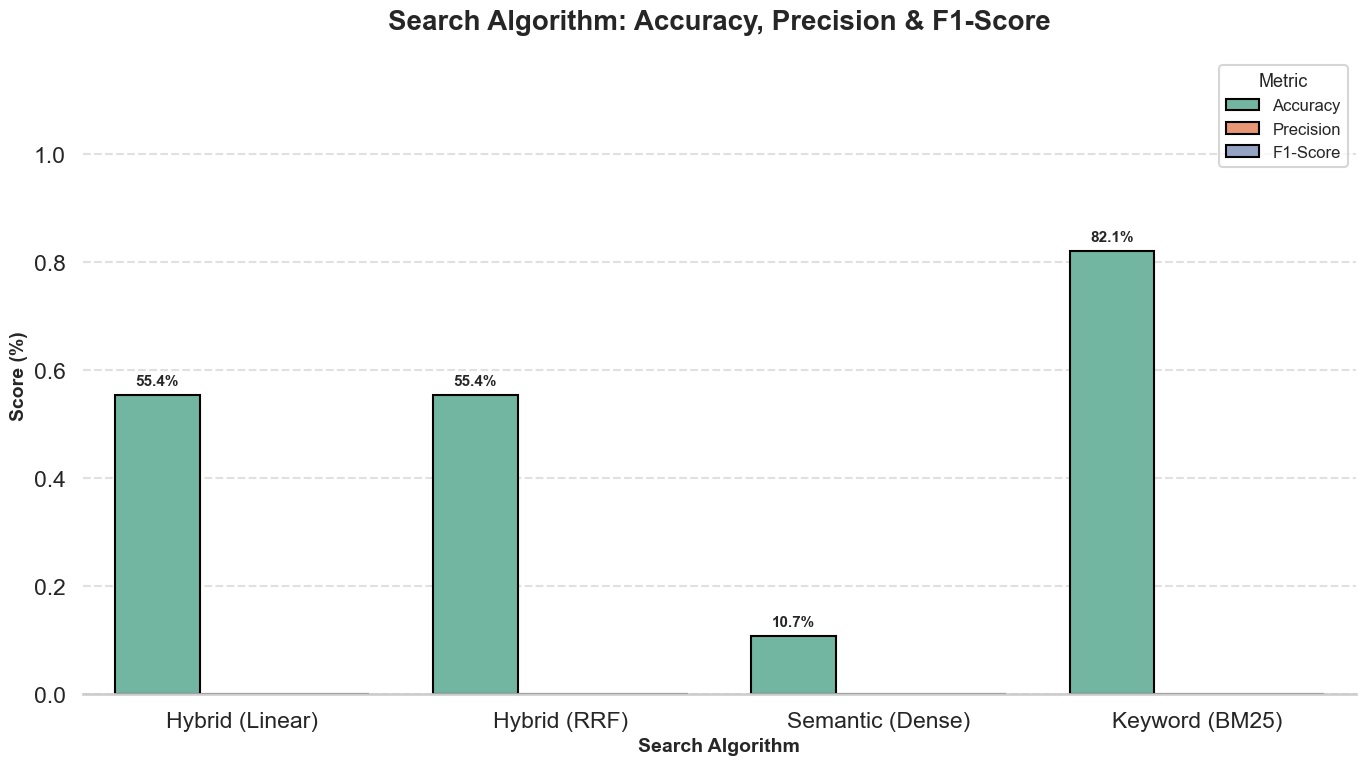

In [95]:
plt.figure(figsize=(14, 8))
df_melted = df_metrics.melt(id_vars='Strategy', value_vars=['Accuracy', 'Precision', 'F1-Score'], var_name='Metric', value_name='Score')
palette = sns.color_palette("Set2")
ax = sns.barplot(x='Strategy', y='Score', hue='Metric', data=df_melted, palette=palette, edgecolor='black', linewidth=1.5)
for p in ax.patches:
    h = p.get_height()
    if h > 0.001:
        ax.annotate(f'{h:.1%}',
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', fontsize=11, fontweight='bold',
                    xytext=(0, 5), textcoords='offset points')
plt.title('Search Algorithm: Accuracy, Precision & F1-Score', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Score (%)', fontsize=14, fontweight='bold')
plt.xlabel('Search Algorithm', fontsize=14, fontweight='bold')
plt.ylim(0, 1.18)
plt.legend(title='Metric', fontsize=12, title_fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine(left=True)
plt.tight_layout()
plt.show()


## Coherency (Agreement) Matrix
How often do two different algorithms return the same result? High % = they agree. This shows which algorithms behave similarly.

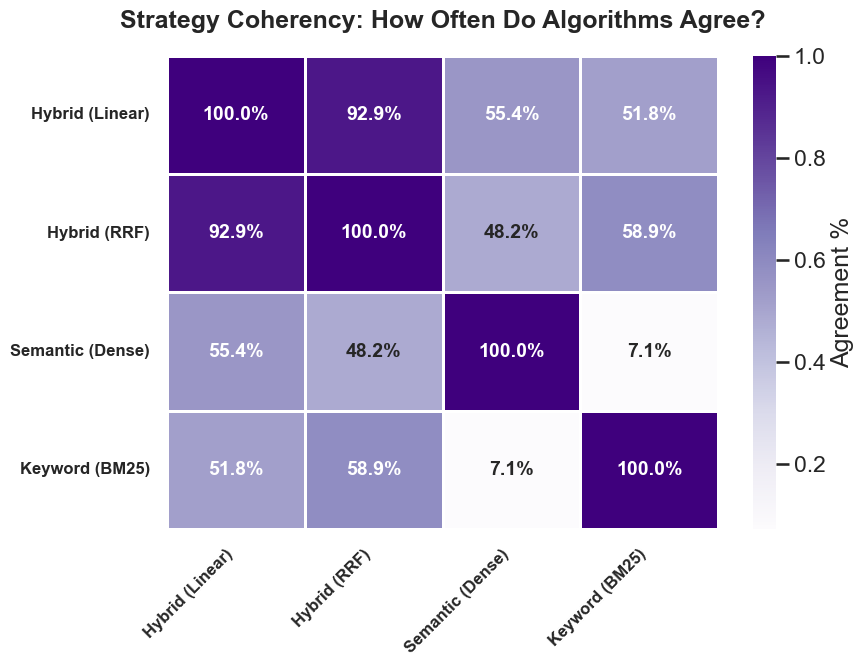

In [96]:
# Only include strategies that have _pred columns
available = [s for s in strategies if f'{s}_pred' in df.columns]
labels = [friendly[s] for s in available]

coh = pd.DataFrame(index=labels, columns=labels, dtype=float)
for s1 in available:
    for s2 in available:
        coh.loc[friendly[s1], friendly[s2]] = accuracy_score(df[f'{s1}_pred'], df[f'{s2}_pred'])

plt.figure(figsize=(9, 7))
sns.heatmap(coh.astype(float), annot=True, fmt=".1%", cmap="Purples", linewidths=2,
            linecolor='white', cbar_kws={'label': 'Agreement %'}, annot_kws={"size": 14, "weight": "bold"})
plt.title("Strategy Coherency: How Often Do Algorithms Agree?", fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold')
plt.yticks(rotation=0, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
